# Image Processing with Discrete Wavelet Transform (DWT)

This notebook demonstrates 2D DWT on an image, including decomposition, analysis of sub-bands, multi-level decomposition, and reconstruction.

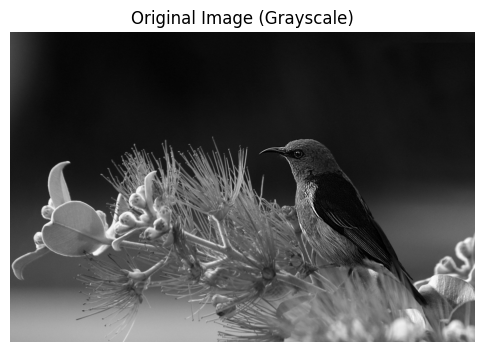

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 1. Load the image and apply image pre-processing techniques
# Loading in grayscale as DWT is typically applied on single channels
image_path = 'lab4/bird.jpg' # Adjust path if necessary
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if image is loaded
if original_img is None:
    print(f"Error: Image not found at {image_path}. Please check the path.")
else:
    # Resize for faster processing if needed, though not strictly necessary
    # original_img = cv2.resize(original_img, (512, 512))
    
    plt.figure(figsize=(6, 6))
    plt.imshow(original_img, cmap='gray')
    plt.title('Original Image (Grayscale)')
    plt.axis('off')
    plt.show()

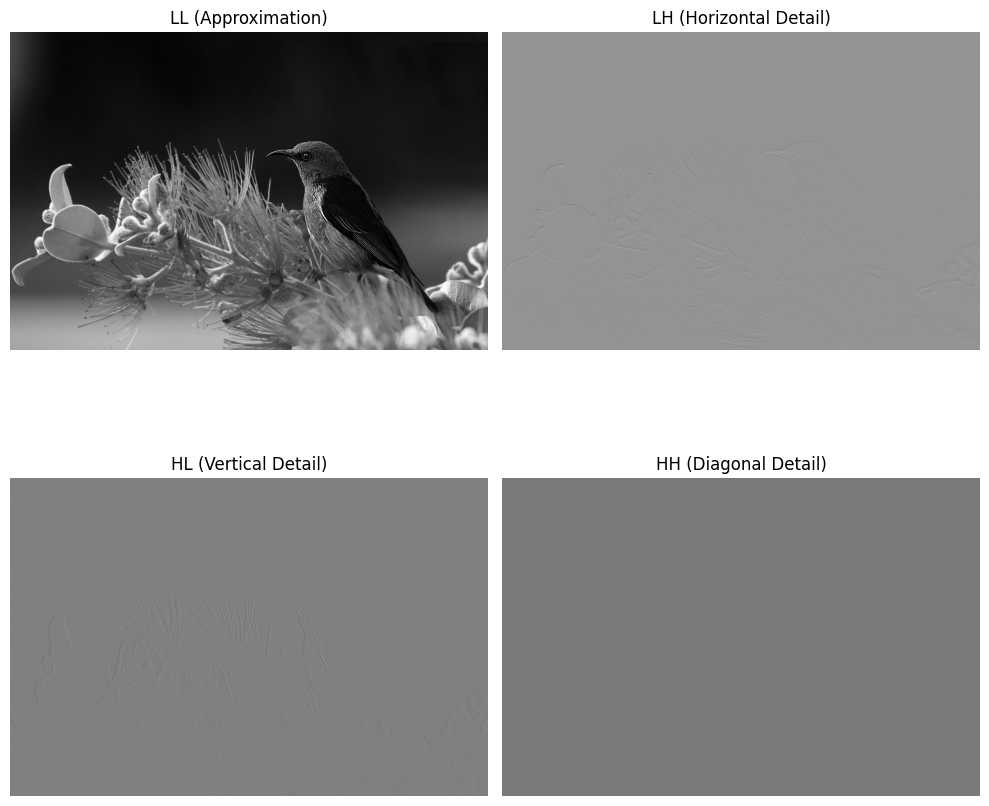

In [2]:
# 2. Apply one level of 2D DWT using 'haar' wavelet
# 3. Decompose the image into LL, LH, HL, HH
coeffs = pywt.dwt2(original_img, 'haar')
LL, (LH, HL, HH) = coeffs

# 4. Display all four sub-band images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = ['LL (Approximation)', 'LH (Horizontal Detail)', 'HL (Vertical Detail)', 'HH (Diagonal Detail)']
images = [LL, LH, HL, HH]

for ax, img, title in zip(axes.flatten(), images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 5. Characteristics of each sub-band
- **LL (Approximation)**: Contains the low-frequency components of the image. It looks like a smoothed, downsampled version of the original image and holds the most significant structural information.
- **LH (Horizontal Detail)**: Captures high-frequency changes along the vertical axis (horizontal edges). It highlights horizontal lines and edges.
- **HL (Vertical Detail)**: Captures high-frequency changes along the horizontal axis (vertical edges). It highlights vertical lines and edges.
- **HH (Diagonal Detail)**: Captures high-frequency changes along the diagonal directions. It highlights diagonal edges and noise.

### 6. Why does the LL band contain most of the important information?
The LL band contains the low-frequency information, which corresponds to the smooth variations in intensity and the overall structure of the image. Since most natural images consist primarily of smooth regions with occasional edges, the majority of the energy and visual information is concentrated in the low frequencies (LL band). The other bands (LH, HL, HH) contain high-frequency details (edges, textures, noise) which are sparse and contain less total energy.

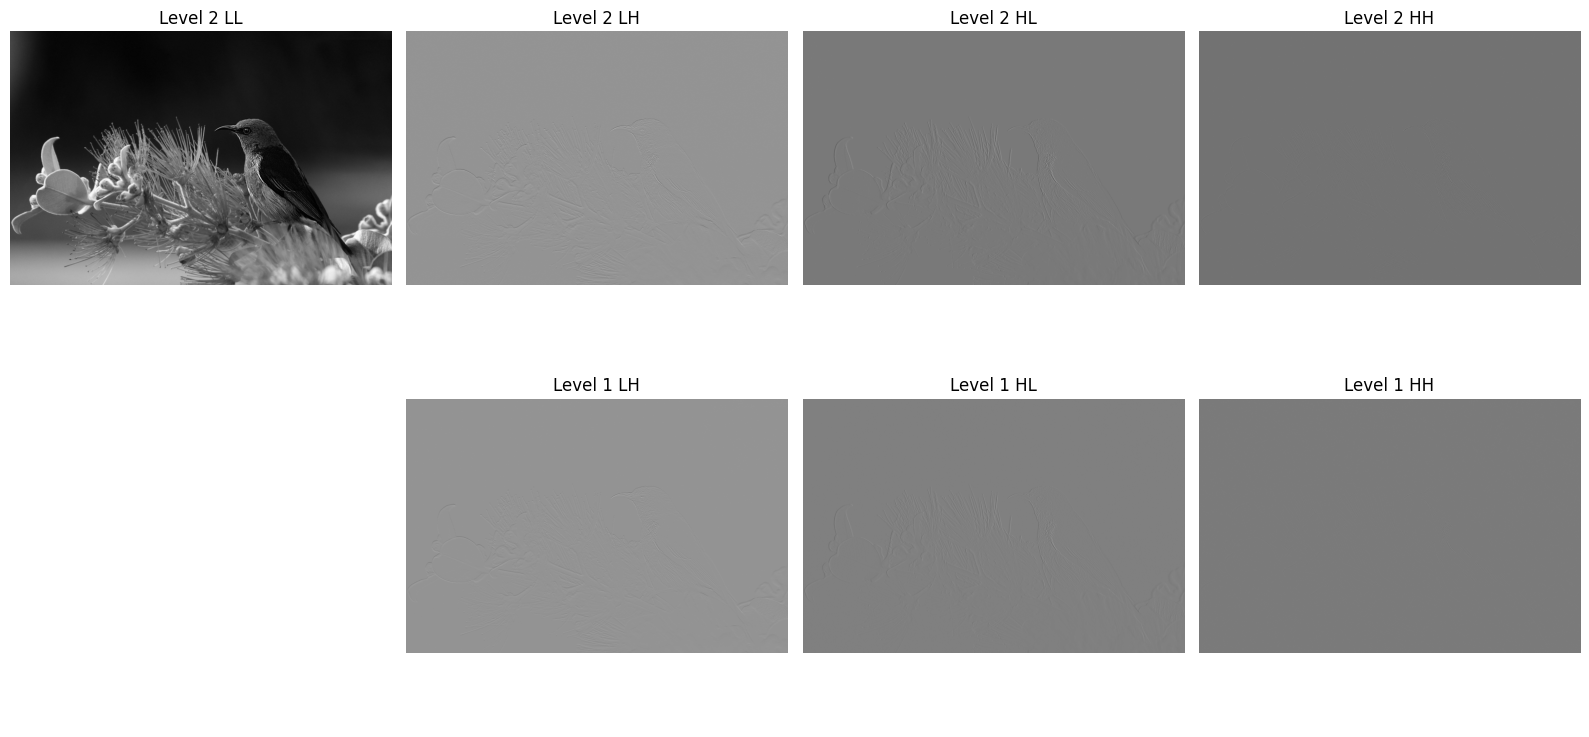

In [3]:
# 7. Apply 2-level wavelet decomposition
coeffs_level2 = pywt.wavedec2(original_img, 'haar', level=2)
LL2, (LH2, HL2, HH2), (LH1, HL1, HH1) = coeffs_level2

# 8. Display all resulting LL and detail components
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Level 2 components
axes[0, 0].imshow(LL2, cmap='gray')
axes[0, 0].set_title('Level 2 LL')
axes[0, 1].imshow(LH2, cmap='gray')
axes[0, 1].set_title('Level 2 LH')
axes[0, 2].imshow(HL2, cmap='gray')
axes[0, 2].set_title('Level 2 HL')
axes[0, 3].imshow(HH2, cmap='gray')
axes[0, 3].set_title('Level 2 HH')

# Level 1 components (from the first decomposition)
axes[1, 0].axis('off') # Placeholder
axes[1, 1].imshow(LH1, cmap='gray')
axes[1, 1].set_title('Level 1 LH')
axes[1, 2].imshow(HL1, cmap='gray')
axes[1, 2].set_title('Level 1 HL')
axes[1, 3].imshow(HH1, cmap='gray')
axes[1, 3].set_title('Level 1 HH')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9. What advantages do multi-level decompositions offer?
- **Multi-resolution Analysis**: Allows analyzing the image at different scales/resolutions, which is useful for detecting features of various sizes.
- **Compression**: Energy is further compacted into a smaller LL band, allowing for more efficient compression (e.g., JPEG 2000).
- **Denoising**: Noise often resides in high-frequency sub-bands at finer scales, so processing these specific levels can effectively remove noise while preserving structures in coarser levels.

### 10. How does the information content change as you proceed to deeper levels?
As you proceed to deeper levels (e.g., Level 1 -> Level 2 -> Level 3):
- The **LL band becomes smaller** (lower resolution) and represents a coarser approximation of the original image.
- The **details (LH, HL, HH) represent increasingly larger scale features** (lower frequency details) of the image.
- The information becomes more **global** and less about fine, local textures.

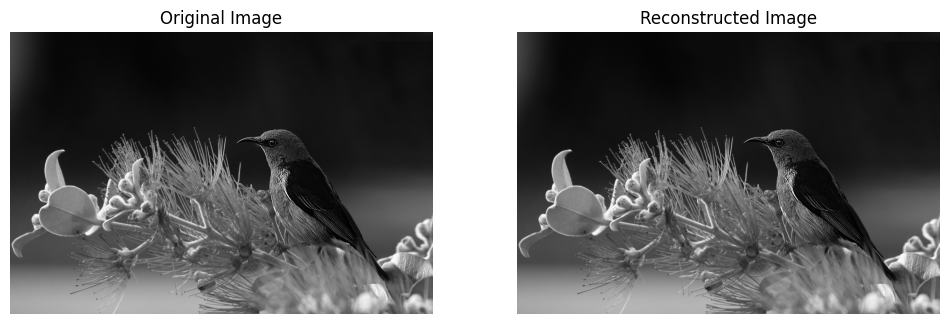

In [4]:
# 11. Apply Inverse wavelet transformation to reconstruct the image
# Reconstructing from the 1-level decomposition for demonstration
reconstructed_img = pywt.idwt2(coeffs, 'haar')

# Display Original vs Reconstructed
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(reconstructed_img, cmap='gray')
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')

plt.show()